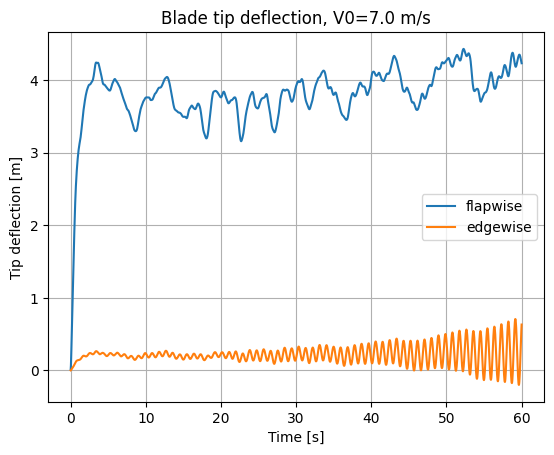

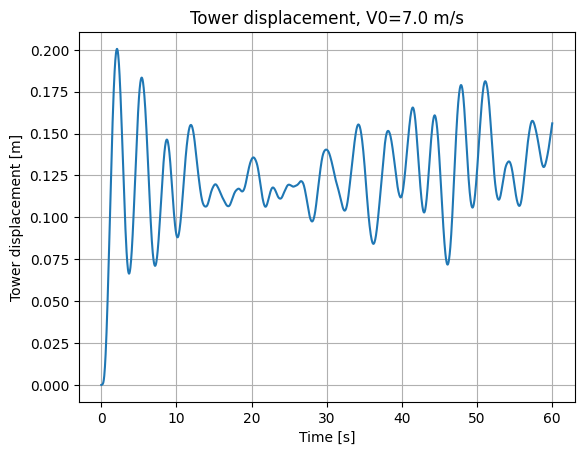

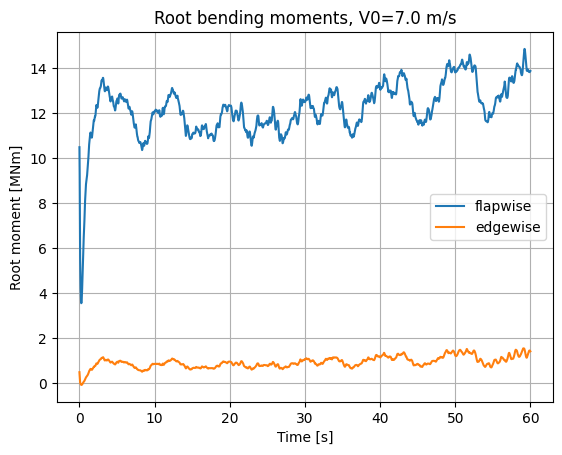

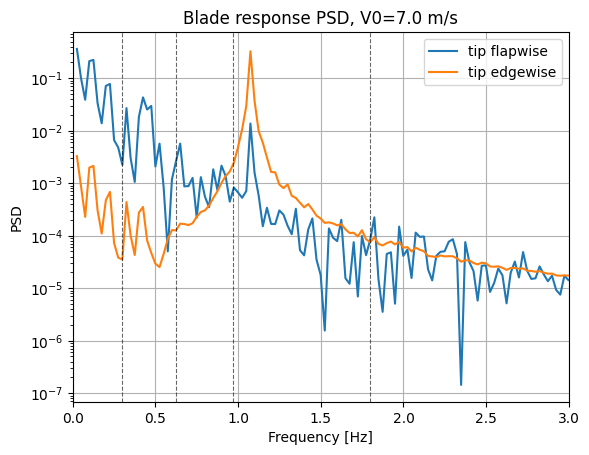

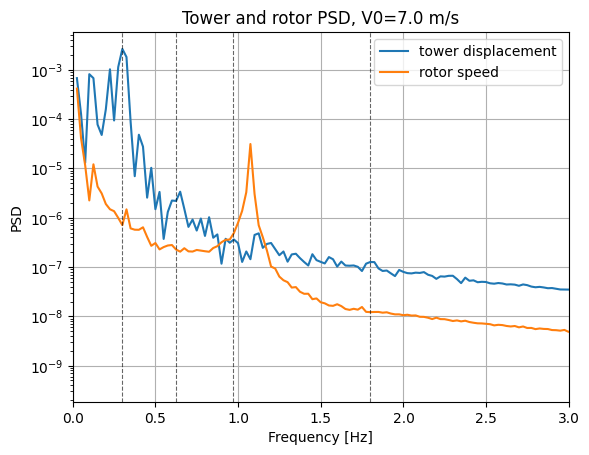

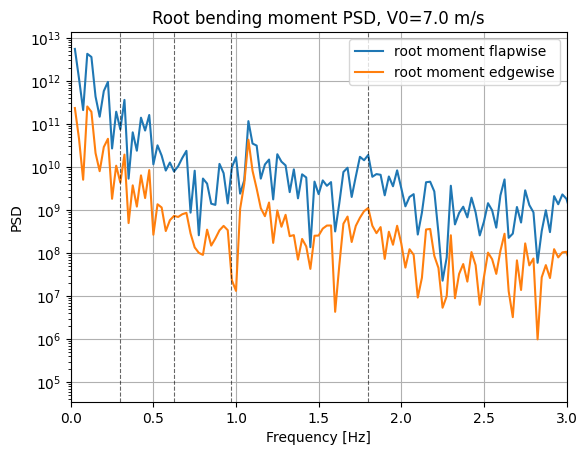

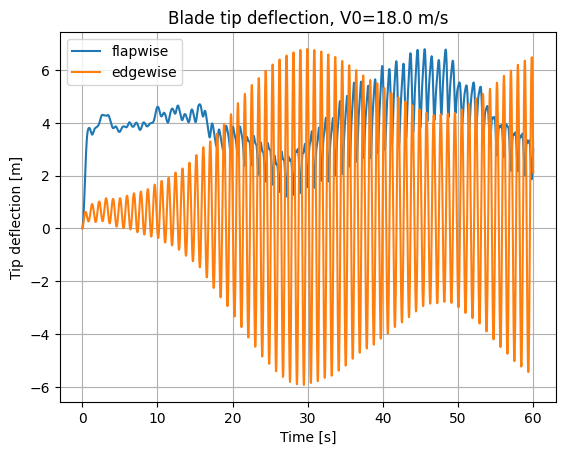

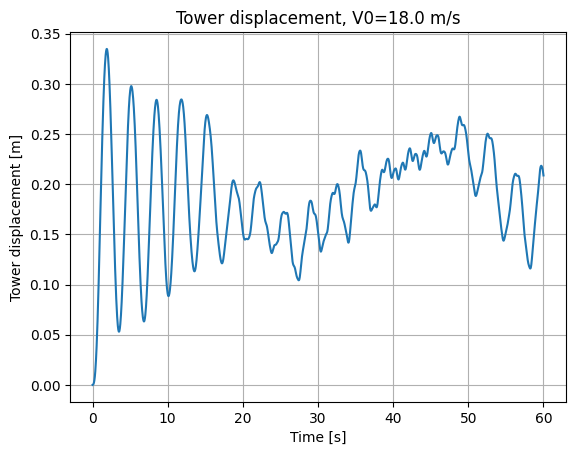

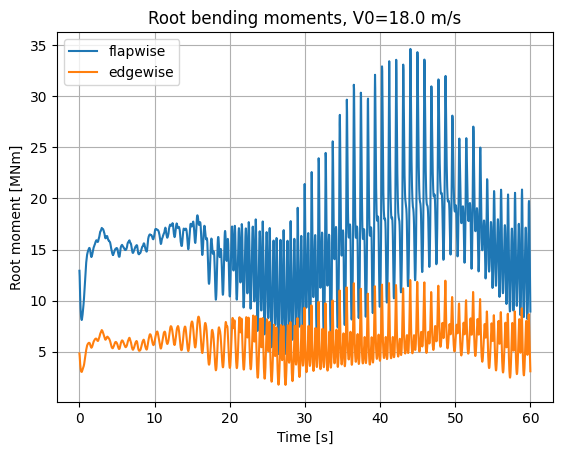

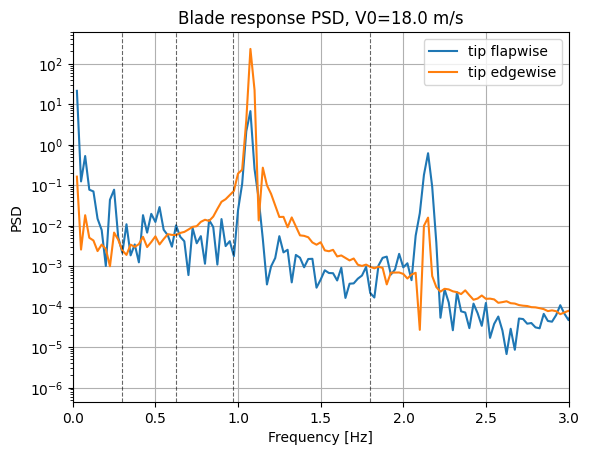

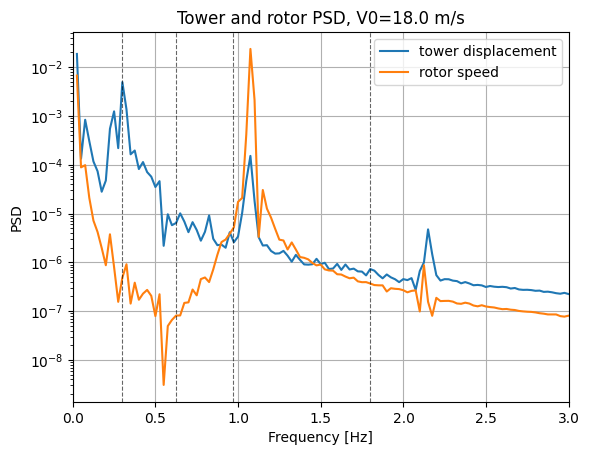

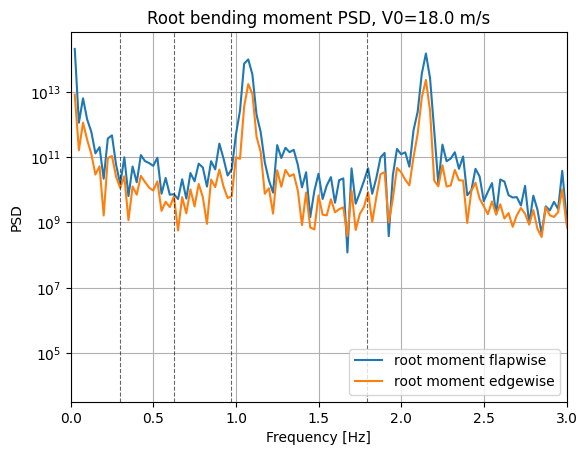

In [25]:
import os
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Assignment 3 - Q1 main simulation and required plots
# Turbulent cases: V0 = 7 m/s and V0 = 18 m/s
# Produces: tip deflection, tower displacement, root moments, PSD
# ============================================================


# ============================================================
# 1) Constants and input files
# ============================================================

# -------------------------
# 1.1 File paths
# -------------------------
DATA_DIR = "."
BLADE_FILE = os.path.join(DATA_DIR, "bladedat.txt")

AIRFOIL_FILES = {
    100.0: os.path.join(DATA_DIR, "cylinder_ds.txt"),
    24.1: os.path.join(DATA_DIR, "FFA-W3-241_ds.txt"),
    30.1: os.path.join(DATA_DIR, "FFA-W3-301_ds.txt"),
    36.0: os.path.join(DATA_DIR, "FFA-W3-360_ds.txt"),
    48.0: os.path.join(DATA_DIR, "FFA-W3-480_ds.txt"),
    60.0: os.path.join(DATA_DIR, "FFA-W3-600_ds.txt"),
}

# -------------------------
# 1.2 Turbine parameters
# -------------------------
B = 3
rho = 1.225
ROTOR_R = None  # set in main()


# -------------------------
# 1.3 Controller parameters
# -------------------------
P_RATED = 10.64e6
I_DRIVETRAIN = 1.6e8

# DTU lecture values
KP = 1.5
KI = 0.64
KK_DEG = 14.0

THETA_MIN_DEG = 0.0
THETA_MAX_DEG = 90.0
PITCH_RATE_MAX_DEG_S = 8.0


# From the lecture slides:
# 1/w0^2 * y¨ + 2*zeta/w0 * y˙ + y = x
# tuned to real Tjaereborg rotor in the slides
USE_SECOND_ORDER_PITCH_ACTUATOR = True
PITCH_ACT_W0 = 8.0
PITCH_ACT_ZETA = 0.7

# -------------------------
# 1.4 Numerical settings
# -------------------------
dt = 0.03
Nsec = 40

F_RELAX = 0.35
TOL_RES = 1e-4
ITMAX = 80

WARM_START = True

# -------------------------
# 1.5 Turbulence settings
# -------------------------

# Dynamic inflow usage 
USE_DYNAMIC_INFLOW_BELOW = False
USE_DYNAMIC_INFLOW_ABOVE = True
USE_DYNAMIC_INFLOW_TURB = True

# Øye model constants 
OYE_K = 0.6
OYE_DENOM_MIN = 0.05


# Turbulence inputs 
H_HUB = 119.0
TURB_ZIP_FILE = os.path.join(DATA_DIR, "Turbulence_generator.zip")
TURB_EXTRACT_DIR = os.path.join(DATA_DIR, "Turbulence_generator")
TURB_INP_FILE = os.path.join(TURB_EXTRACT_DIR, "inputEx3.inp")
TURB_U_FILE = os.path.join(DATA_DIR, "sim1.bin")


def rotor_radius():
    if ROTOR_R is None:
        raise RuntimeError("ROTOR_R has not been initialised yet. Call main() first.")
    return ROTOR_R


# -------------------------
# 1.6 Structural parameters for Assignment 3
# -------------------------

M_NACELLE = 446000.0      # kg
K_TOWER = 1.7e6           # N/m

N_DOF_5 = 5

# Structural damping
LOG_DEC = 0.03            # 3% logarithmic decrement
ZETA_STRUCT = LOG_DEC / (2.0 * np.pi)

MODE_FILE = os.path.join(DATA_DIR, "modeshapes.txt")

FIXED_OMEGA_DEBUG = False   # False = dynamic rotor speed
OMEGA_FIXED = 0.72          # used only if FIXED_OMEGA_DEBUG=True


# ============================================================
# 1) Blade geometry and airfoil data
# ============================================================

# -------------------------
# 2.1 Blade geometry
# -------------------------
def read_bladedat(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing blade file: {path}")

    data = np.loadtxt(path)
    if data.ndim != 2 or data.shape[1] < 4:
        raise ValueError("bladedat.txt must have >= 4 columns")

    r = data[:, 0]
    tc = data[:, 3]
    beta_deg = data[:, 1]
    c = data[:, 2]

    if np.nanmax(tc) <= 1.5:
        tc = tc * 100.0

    idx = np.argsort(r)
    return r[idx], c[idx], beta_deg[idx], tc[idx]


def build_sections(r_tab, c_tab, beta_deg_tab, tc_tab, nsec):
    r0 = float(np.min(r_tab))
    Rtip = float(np.max(r_tab))
    r_sec = np.linspace(r0, 0.98 * Rtip, nsec)

    c_sec = np.interp(r_sec, r_tab, c_tab)
    beta_deg_sec = np.interp(r_sec, r_tab, beta_deg_tab)
    tc_sec = np.interp(r_sec, r_tab, tc_tab)

    return Rtip, r_sec, c_sec, beta_deg_sec, tc_sec


# -------------------------
# 2.2 Airfoil polar data
# -------------------------
def read_polar_file(path):
    tbl = np.loadtxt(path, ndmin=2)
    if tbl.shape[1] < 3:
        raise ValueError(f"{path} must have >= 3 columns: alpha, Cl, Cd")

    alpha = tbl[:, 0]
    cl = tbl[:, 1]
    cd = tbl[:, 2]

    order = np.argsort(alpha)
    return alpha[order], cl[order], cd[order]


def load_airfoils(files_dict):
    items = sorted(files_dict.items(), key=lambda kv: kv[0])
    thick = np.array([tc for tc, _ in items], dtype=float)

    aoa_cols, cl_cols, cd_cols = [], [], []
    for _, fname in items:
        if not os.path.exists(fname):
            raise FileNotFoundError(f"Missing airfoil file: {fname}")

        a, cl, cd = read_polar_file(fname)
        aoa_cols.append(a)
        cl_cols.append(cl)
        cd_cols.append(cd)

    return thick, aoa_cols, cl_cols, cd_cols


THICK, AOA_COLS, CL_COLS, CD_COLS = load_airfoils(AIRFOIL_FILES)

# -------------------------
# 2.3 Aerodynamic interpolation
# -------------------------
def interp_extrap(x, xp, yp):
    x = float(x)
    xp = np.asarray(xp, dtype=float)
    yp = np.asarray(yp, dtype=float)

    if x <= xp[0]:
        x0, x1 = xp[0], xp[1]
        y0, y1 = yp[0], yp[1]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

    if x >= xp[-1]:
        x0, x1 = xp[-2], xp[-1]
        y0, y1 = yp[-2], yp[-1]
        return y1 + (y1 - y0) * (x - x1) / (x1 - x0)

    return float(np.interp(x, xp, yp))


def cl_cd_double_interp(alpha_deg, tc_percent):
    tc = float(np.clip(tc_percent, THICK.min(), THICK.max()))
    cl_thk = np.empty(len(THICK))
    cd_thk = np.empty(len(THICK))

    for k in range(len(THICK)):
        cl_thk[k] = interp_extrap(alpha_deg, AOA_COLS[k], CL_COLS[k])
        cd_thk[k] = interp_extrap(alpha_deg, AOA_COLS[k], CD_COLS[k])

    cl = float(np.interp(tc, THICK, cl_thk))
    cd = float(np.interp(tc, THICK, cd_thk))
    return cl, cd


# ============================================================
# 3) Aerodynamic model (BEM)
# ============================================================

# -------------------------
# 3.1 Tip-loss correction
# -------------------------
def prandtl_tip_loss(B, r, R, phi):
    sphi = abs(np.sin(phi))
    sphi = max(sphi, 1e-12)

    ftip = (B * (R - r)) / (2.0 * r * sphi)
    ftip = max(0.0, ftip)

    F = (2.0 / np.pi) * np.arccos(np.exp(-ftip))
    return float(np.clip(F, 1e-6, 1.0))


# -------------------------
# 3.2 Induction solver
# -------------------------
def solve_a_ap_qs(V0, Omega, r, chord, twist_deg, pitch_deg, tc_percent, a_init, ap_init):
    R = rotor_radius()

    theta_p = np.deg2rad(pitch_deg)
    twist = np.deg2rad(twist_deg)

    a = float(a_init)
    ap = float(ap_init)

    a_new = 0.10 if abs(a_init) < 1e-15 else float(a_init)
    ap_new = 0.00 if abs(ap_init) < 1e-15 else float(ap_init)

    it = 0
    while True:
        it += 1
        a, ap = a_new, ap_new

        denom = (1.0 + ap) * Omega * r + 1e-12
        phi = np.arctan(((1.0 - a) * V0) / denom)
        alpha_deg = np.rad2deg(phi - (twist + theta_p))

        Cl, Cd = cl_cd_double_interp(alpha_deg, tc_percent)

        Cn = Cl * np.cos(phi) + Cd * np.sin(phi)
        Ct = Cl * np.sin(phi) - Cd * np.cos(phi)

        sigma = (B * chord) / (2.0 * np.pi * r + 1e-12)
        F = prandtl_tip_loss(B, r, R, phi)

        sphi = np.sin(phi)
        cphi = np.cos(phi)

        a_fix = (sigma * Cn * (1.0 - a)) / (4.0 * F * sphi**2 + 1e-12)
        ap_fix = (sigma * Ct * (1.0 + ap)) / (4.0 * F * sphi * cphi + 1e-12)

        if a > 0.33:
            dCT = ((1.0 - a)**2 * Cn * sigma) / (sphi**2 + 1e-12)
            a_fix = dCT / (4.0 * F * (1.0 - 0.25 * (5.0 - 3.0 * a) * a) + 1e-12)

        a_new = np.clip(a + F_RELAX * (a_fix - a), 0.0, 0.95)
        ap_new = np.clip(ap + F_RELAX * (ap_fix - ap), -0.5, 1.0)

        if max(abs(a_fix - a), abs(ap_fix - ap)) < TOL_RES or it >= ITMAX:
            return float(a_new), float(ap_new)

# -------------------------
# 3.3 Loads from a/ap
# -------------------------
def loads_from_a_ap(V0, Omega, r, chord, twist_deg, pitch_deg, tc_percent, a, ap):
    theta_p = np.deg2rad(pitch_deg)
    twist = np.deg2rad(twist_deg)

    denom = (1.0 + ap) * Omega * r + 1e-12
    phi = np.arctan(((1.0 - a) * V0) / denom)
    alpha_deg = np.rad2deg(phi - (twist + theta_p))

    Cl, Cd = cl_cd_double_interp(alpha_deg, tc_percent)

    Vrel = np.sqrt(((1.0 - a) * V0)**2 + ((1.0 + ap) * Omega * r)**2)
    L = 0.5 * rho * Vrel**2 * chord * Cl
    D = 0.5 * rho * Vrel**2 * chord * Cd

    fT = L * np.sin(phi) - D * np.cos(phi)
    fN = L * np.cos(phi) + D * np.sin(phi)
    return float(fN), float(fT)

# -------------------------
# 3.4 Øye dynamic inflow helpers
# -------------------------
def oye_time_constants(V0, a, r):
    R = rotor_radius()
    V0 = max(float(V0), 0.1)
    a = float(np.clip(a, 0.0, 0.95))
    denom = max(1.0 - 1.3 * a, OYE_DENOM_MIN)

    tau1 = (1.1 / denom) * (R / V0)
    tau2 = (0.39 - 0.26 * (r / R)**2) * tau1
    return float(tau1), float(max(tau2, 1e-6))


def init_dynamic_inflow_states(a_state, Vz_local):
    Wz_state = -np.asarray(a_state, dtype=float) * np.asarray(Vz_local, dtype=float)
    Wint_state = Wz_state.copy()
    Wqs_prev = Wz_state.copy()
    return Wz_state, Wint_state, Wqs_prev


def update_dynamic_inflow(a_qs, a_actual, V0, r, dt_local, Wz_state, Wint_state, Wqs_prev, use_dynamic_inflow):
    if not use_dynamic_inflow:
        Wz_new = -a_qs * V0
        return float(np.clip(a_qs, 0.0, 0.95)), float(Wz_new), float(Wz_new), float(Wz_new)

    Wqs = -a_qs * V0
    tau1, tau2 = oye_time_constants(V0, a_actual, r)

    fac1 = dt_local / tau1
    fac2 = dt_local / tau2

    Wint_new = Wint_state + fac1 * (Wqs - Wint_state) + OYE_K * (Wqs - Wqs_prev)
    Wz_new = Wz_state + fac2 * (Wint_new - Wz_state)
    a_new = np.clip(-Wz_new / max(V0, 0.1), 0.0, 0.95)

    return float(a_new), float(Wz_new), float(Wint_new), float(Wqs)


# -------------------------
# 3.5 Warm start
# -------------------------
def warm_start_induction(a_state, ap_state, r_sec, c_sec, beta_deg_sec, tc_sec, Vz_local, pitch_deg, Omega):
    for j in range(len(r_sec)):
        a_state[j], ap_state[j] = solve_a_ap_qs(
            Vz_local[j],
            Omega,
            r_sec[j],
            c_sec[j],
            beta_deg_sec[j],
            pitch_deg,
            tc_sec[j],
            a_state[j],
            ap_state[j],
        )
    return init_dynamic_inflow_states(a_state, Vz_local)



def generator_torque(omega, K, omega_rated):
    if omega < omega_rated:
        return float(K * omega**2)
    return float(P_RATED / max(omega, 1e-12))


# ============================================================
# 4) Pitch controller and actuator model
# ============================================================

# -------------------------
# 4.1 Helper functions
# -------------------------
def clamp(x, xmin, xmax):
    return max(xmin, min(x, xmax))


def gain_reduction(theta_p_deg):
    return 1.0 / (1.0 + theta_p_deg / KK_DEG)

# -------------------------
# 4.2 Pitch actuator
# -------------------------
def apply_pitch_rate_limit(pitch_deg_old, pitch_deg_new, dt_local):
    dpitch_max = PITCH_RATE_MAX_DEG_S * dt_local
    dpitch = np.clip(pitch_deg_new - pitch_deg_old, -dpitch_max, dpitch_max)
    return float(clamp(pitch_deg_old + dpitch, THETA_MIN_DEG, THETA_MAX_DEG))


def pitch_actuator_filter(theta_cmd_deg, pitch_deg, pitch_rate_deg_s, dt_local):
    """
    Second-order actuator model from the lecture:
    1/w0^2 * y¨ + 2*zeta/w0 * y˙ + y = x

    Integrated here in simple state-space form.
    """
    if not USE_SECOND_ORDER_PITCH_ACTUATOR:
        pitch_new = apply_pitch_rate_limit(pitch_deg, theta_cmd_deg, dt_local)
        pitch_rate_new = (pitch_new - pitch_deg) / max(dt_local, 1e-12)
        return pitch_new, pitch_rate_new

    # y¨ = w0^2 (x - y) - 2*zeta*w0*y˙
    pitch_acc_deg_s2 = (PITCH_ACT_W0**2) * (theta_cmd_deg - pitch_deg) - 2.0 * PITCH_ACT_ZETA * PITCH_ACT_W0 * pitch_rate_deg_s

    pitch_rate_pred = pitch_rate_deg_s + dt_local * pitch_acc_deg_s2
    pitch_pred = pitch_deg + dt_local * pitch_rate_pred

    pitch_limited = apply_pitch_rate_limit(pitch_deg, pitch_pred, dt_local)
    pitch_rate_limited = (pitch_limited - pitch_deg) / max(dt_local, 1e-12)

    return float(pitch_limited), float(pitch_rate_limited)


# -------------------------
# 4.3 PI pitch controller
# -------------------------
def update_collective_pitch_controller(omega, rated, pitch_deg, theta_I_deg, dt_local):
    """
    PI implementation following the lecture logic:
    - proportional and integral terms scaled by gain reduction GK
    - integral term limited separately
    - total setpoint limited separately
    """
    error = omega - rated["omega_ref"]
    GK = gain_reduction(pitch_deg)

    theta_P_deg = np.rad2deg(KP * error) * GK
    theta_I_trial = theta_I_deg + np.rad2deg(KI * error * dt_local) * GK

    # Limit integral term
    theta_I_new = clamp(theta_I_trial, 0.0, 25.0)

    # Limit total pitch command
    theta_set_deg = clamp(theta_P_deg + theta_I_new, 0.0, 30.0)

    return float(theta_set_deg), float(theta_I_new), float(error), float(theta_P_deg)


# ============================================================
# 5) Turbulence model (Mann box)
# ============================================================

# -------------------------
# 5.1 File handling
# -------------------------
def ensure_turbulence_files_exist():
    if os.path.exists(TURB_U_FILE):
        return

    if not os.path.exists(TURB_ZIP_FILE):
        raise FileNotFoundError(
            "No sim1.bin found next to the notebook, and Turbulence_generator.zip is also missing."
        )

    os.makedirs(TURB_EXTRACT_DIR, exist_ok=True)

    with zipfile.ZipFile(TURB_ZIP_FILE, "r") as zf:
        zf.extractall(DATA_DIR)

    sim1_extracted = os.path.join(TURB_EXTRACT_DIR, "sim1.bin")
    if not os.path.exists(sim1_extracted):
        raise FileNotFoundError(
            "Extracted Turbulence_generator.zip, but could not find Turbulence_generator/sim1.bin."
        )

    if not os.path.exists(TURB_U_FILE):
        shutil.copy(sim1_extracted, TURB_U_FILE)

# -------------------------
# 5.2 Input parsing
# -------------------------
def read_mann_inp(path):
    if not os.path.exists(path):
        return None

    lines = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for ln in f:
            ln = ln.strip()
            if ln:
                lines.append(ln)

    if len(lines) < 12:
        return None

    n1 = int(float(lines[3]))
    n2 = int(float(lines[4]))
    n3 = int(float(lines[5]))

    Lx = float(lines[6])
    Ly = float(lines[7])
    Lz = float(lines[8])

    umean = float(lines[10]) if len(lines) > 10 else None
    hhub = float(lines[11]) if len(lines) > 11 else H_HUB

    return {"n1": n1, "n2": n2, "n3": n3, "Lx": Lx, "Ly": Ly, "Lz": Lz, "umean": umean, "hhub": hhub}

# -------------------------
# 5.3 Turbulence loading
# -------------------------
def load_mann_bin_3d(filename, n1, n2, n3):
    data = np.fromfile(filename, dtype=np.dtype("<f4"), count=n1 * n2 * n3)
    if data.size != n1 * n2 * n3:
        raise ValueError(f"{filename} has {data.size} floats, expected {n1 * n2 * n3}.")
    return data.reshape((n1, n2, n3), order="C")

# -------------------------
# 5.4 Spatial interpolation
# -------------------------
def bilinear_interp_plane(u_plane, y_grid, z_grid, y_pos, z_pos):
    y_grid = np.asarray(y_grid, dtype=float)
    z_grid = np.asarray(z_grid, dtype=float)
    y_pos = np.asarray(y_pos, dtype=float)
    z_pos = np.asarray(z_pos, dtype=float)

    ny = len(y_grid)
    nz = len(z_grid)

    y_pos_c = np.clip(y_pos, y_grid[0], y_grid[-1])
    z_pos_c = np.clip(z_pos, z_grid[0], z_grid[-1])

    iy = np.searchsorted(y_grid, y_pos_c) - 1
    iz = np.searchsorted(z_grid, z_pos_c) - 1

    iy = np.clip(iy, 0, ny - 2)
    iz = np.clip(iz, 0, nz - 2)

    y0 = y_grid[iy]
    y1 = y_grid[iy + 1]
    z0 = z_grid[iz]
    z1 = z_grid[iz + 1]

    ty = (y_pos_c - y0) / np.maximum(y1 - y0, 1e-12)
    tz = (z_pos_c - z0) / np.maximum(z1 - z0, 1e-12)

    v00 = u_plane[iy, iz]
    v10 = u_plane[iy + 1, iz]
    v01 = u_plane[iy, iz + 1]
    v11 = u_plane[iy + 1, iz + 1]

    v0 = v00 * (1.0 - ty) + v10 * ty
    v1 = v01 * (1.0 - ty) + v11 * ty

    return v0 * (1.0 - tz) + v1 * tz


# ============================================================
# 6) Structural model (5DOF) - Assignment 3
# ============================================================

# -------------------------
# 6.1 Mode shapes
# -------------------------
def read_mode_shapes(path):
    """
    Reads mode shapes from file.

    Returns
    -------
    dict
        Contains mode shapes and natural frequencies
    """
    data = np.loadtxt(path, comments="#")

    r = data[:, 0]
    u1fy = data[:, 1]
    u1fz = data[:, 2]
    u1ey = data[:, 3]
    u1ez = data[:, 4]
    u2fy = data[:, 5]
    u2fz = data[:, 6]
    m = data[:, 7]

    omega_1f = 3.93
    omega_1e = 6.10
    omega_2f = 11.28

    return {
        "r": r,
        "m": m,
        "u1fy": u1fy,
        "u1fz": u1fz,
        "u1ey": u1ey,
        "u1ez": u1ez,
        "u2fy": u2fy,
        "u2fz": u2fz,
        "omega": np.array([omega_1f, omega_1e, omega_2f])
    }


def interpolate_modes_to_sections(modes_raw, r_sec):
    modes = {}

    modes["r"] = r_sec
    modes["m"] = np.interp(r_sec, modes_raw["r"], modes_raw["m"])

    modes["u1fy"] = np.interp(r_sec, modes_raw["r"], modes_raw["u1fy"])
    modes["u1fz"] = np.interp(r_sec, modes_raw["r"], modes_raw["u1fz"])

    modes["u1ey"] = np.interp(r_sec, modes_raw["r"], modes_raw["u1ey"])
    modes["u1ez"] = np.interp(r_sec, modes_raw["r"], modes_raw["u1ez"])

    modes["u2fy"] = np.interp(r_sec, modes_raw["r"], modes_raw["u2fy"])
    modes["u2fz"] = np.interp(r_sec, modes_raw["r"], modes_raw["u2fz"])

    modes["omega"] = modes_raw["omega"]

    return modes


# -------------------------
# 6.2 Generalized mass
# -------------------------
def generalized_mass(r, m, uy, uz):
    return np.trapz(m * (uy**2 + uz**2), r)

# -------------------------
# 6.3 System matrices
# -------------------------
def build_5dof_matrices(r, modes):
    """
    Builds mass and stiffness matrices for 5-DOF system.

    DOFs:
    0 = tower
    1 = rotor
    2 = 1st flap
    3 = 1st edge
    4 = 2nd flap

    Returns
    -------
    M : ndarray
        Mass matrix
    K : ndarray
        Stiffness matrix
    """

    M = np.zeros((5, 5))
    K = np.zeros((5, 5))

    m = modes["m"]

    # Mode shapes
    uy1 = modes["u1fy"]
    uz1 = modes["u1fz"]

    uy2 = modes["u1ey"]
    uz2 = modes["u1ez"]

    uy3 = modes["u2fy"]
    uz3 = modes["u2fz"]

    omega1, omega2, omega3 = modes["omega"]

    # Generalized modal masses
    GM1 = generalized_mass(r, m, uy1, uz1)
    GM2 = generalized_mass(r, m, uy2, uz2)
    GM3 = generalized_mass(r, m, uy3, uz3)

    # -------------------------
    # Mass matrix
    # DOF 0: tower z
    # DOF 1: rotor azimuth theta
    # DOF 2: q1 = 1f
    # DOF 3: q2 = 1e
    # DOF 4: q3 = 2f
    # -------------------------

    M[0, 0] = M_NACELLE + np.trapz(m, r)
    M[1, 1] = I_DRIVETRAIN + np.trapz(m * r**2, r)

    M[2, 2] = GM1
    M[3, 3] = GM2
    M[4, 4] = GM3

    # Tower/modal coupling through z-deflection
    M[0, 2] = np.trapz(m * uz1, r)
    M[2, 0] = M[0, 2]

    M[0, 3] = np.trapz(m * uz2, r)
    M[3, 0] = M[0, 3]

    M[0, 4] = np.trapz(m * uz3, r)
    M[4, 0] = M[0, 4]

    # Azimuth/modal coupling through y-deflection
    M[1, 2] = np.trapz(m * r * uy1, r)
    M[2, 1] = M[1, 2]

    M[1, 3] = np.trapz(m * r * uy2, r)
    M[3, 1] = M[1, 3]

    M[1, 4] = np.trapz(m * r * uy3, r)
    M[4, 1] = M[1, 4]

    # -------------------------
    # Stiffness matrix
    # -------------------------
    K[0, 0] = K_TOWER
    K[1, 1] = 0.0

    K[2, 2] = GM1 * omega1**2
    K[3, 3] = GM2 * omega2**2
    K[4, 4] = GM3 * omega3**2

    return M, K


def build_damping_matrix(M, K):
    C = np.zeros_like(M)

    for i in range(M.shape[0]):
        if M[i, i] > 0 and K[i, i] > 0:
            omega_i = np.sqrt(K[i, i] / M[i, i])
            C[i, i] = 2.0 * ZETA_STRUCT * M[i, i] * omega_i

    return C

# ============================================================
# 7) Aeroelastic coupling
# ============================================================

# -------------------------
# 7.1 Generalized forces
# -------------------------

def generalized_forces_5dof(r, fN, fT, modes, omega, gen=None):
    """
    Computes generalized forces for 5-DOF system.

    Includes:
    - aerodynamic thrust
    - aerodynamic torque
    - modal forces

    Returns
    -------
    GF : ndarray
        Generalized force vector
    """

    GF = np.zeros(5)

    # Tower force
    GF[0] = np.trapz(fN, r)

    # Aerodynamic torque
    Q_aero = np.trapz(fT * r, r)

    # Rotor equation
    if FIXED_OMEGA_DEBUG:
        GF[1] = 0.0
    else:
        if gen is None:
            M_gen = 0.0
        elif gen["mode"] == "quadratic":
            M_gen = gen["K"] * omega**2
        elif gen["mode"] == "constant_power":
            M_gen = gen["P"] / max(omega, 0.05)
        else:
            M_gen = 0.0

        GF[1] = Q_aero - M_gen

    # Modal generalized forces
    GF[2] = np.trapz(fT * modes["u1fy"] + fN * modes["u1fz"], r)
    GF[3] = np.trapz(fT * modes["u1ey"] + fN * modes["u1ez"], r)
    GF[4] = np.trapz(fT * modes["u2fy"] + fN * modes["u2fz"], r)

    return GF

# -------------------------
# 7.2 Blade velocities
# -------------------------

def blade_velocity_5dof(xd, modes):
    """
    Computes blade velocity from the modal velocities.

    xd[0] = tower velocity
    xd[1] = rotor speed omega
    xd[2] = q1dot
    xd[3] = q2dot
    xd[4] = q3dot
    """

    q1dot = xd[2]
    q2dot = xd[3]
    q3dot = xd[4]

    uy_dot = (
        q1dot * modes["u1fy"]
        + q2dot * modes["u1ey"]
        + q3dot * modes["u2fy"]
    )

    uz_dot = (
        q1dot * modes["u1fz"]
        + q2dot * modes["u1ez"]
        + q3dot * modes["u2fz"]
    )

    return uy_dot, uz_dot

# -------------------------
# 7.3 Aeroelastic loads
# -------------------------

def loads_from_a_ap_aeroelastic(
    V0,
    omega,
    r,
    chord,
    twist_deg,
    pitch_deg,
    tc_percent,
    a,
    ap,
    tower_vel,
    uy_dot,
    uz_dot,
):
    theta_p = np.deg2rad(pitch_deg)
    twist = np.deg2rad(twist_deg)

    V_axial = (1.0 - a) * V0 - tower_vel - uz_dot
    V_tan = (1.0 + ap) * omega * r - uy_dot

    # numerical safety
    V_axial = np.clip(V_axial, -80.0, 80.0)
    V_tan = np.clip(V_tan, -250.0, 250.0)

    if abs(V_tan) < 1e-6:
        V_tan = 1e-6

    phi = np.arctan2(V_axial, V_tan)
    alpha_deg = np.rad2deg(phi - (twist + theta_p))

    Cl, Cd = cl_cd_double_interp(alpha_deg, tc_percent)

    Vrel = np.sqrt(V_axial**2 + V_tan**2)

    L = 0.5 * rho * Vrel**2 * chord * Cl
    D = 0.5 * rho * Vrel**2 * chord * Cd

    fT = L * np.sin(phi) - D * np.cos(phi)
    fN = L * np.cos(phi) + D * np.sin(phi)

    return float(fN), float(fT)

# -------------------------
# 7.4 Steady load computation

# This function def compute_blade_loads_q1(...) computes aerodynamic loads for a *steady (uniform) wind* case.
# It is still needed for:
# 1) Debugging and verifying the aeroelastic model without turbulence
# 2) Computing initial conditions (e.g. generator torque balance K_gen_q1)
# 3) Providing a clean reference case without turbulent excitation
# -------------------------

def compute_blade_loads_q1(
    V0,
    omega,
    pitch_deg,
    r_sec,
    c_sec,
    beta_deg_sec,
    tc_sec,
    a_state,
    ap_state,
    x,
    xd,
    modes,
):
    """
    Computes aerodynamic loads for uniform inflow.

    Used for:
    - steady simulations
    - initialization
    """

    fN = np.zeros_like(r_sec)
    fT = np.zeros_like(r_sec)

    tower_vel = xd[0]
    uy_dot, uz_dot = blade_velocity_5dof(xd, modes)

    for j in range(len(r_sec)):

        # Effective axial wind seen by BEM induction solver
        V0_eff = V0 - tower_vel - uz_dot[j]
        V0_eff = max(V0_eff, 0.1)

        a_state[j], ap_state[j] = solve_a_ap_qs(
            V0_eff,
            omega,
            r_sec[j],
            c_sec[j],
            beta_deg_sec[j],
            pitch_deg,
            tc_sec[j],
            a_state[j],
            ap_state[j],
        )

        fN[j], fT[j] = loads_from_a_ap_aeroelastic(
            V0,
            omega,
            r_sec[j],
            c_sec[j],
            beta_deg_sec[j],
            pitch_deg,
            tc_sec[j],
            a_state[j],
            ap_state[j],
            tower_vel,
            uy_dot[j],
            uz_dot[j],
        )

    return fN, fT, a_state, ap_state

# -------------------------
# 7.5 Turbulent load computation
# -------------------------
def compute_blade_loads_q1_turbulent(
    V0_local,
    omega,
    pitch_deg,
    r_sec,
    c_sec,
    beta_deg_sec,
    tc_sec,
    a_state,
    ap_state,
    x,
    xd,
    modes,
):
    """
    Computes aerodynamic loads for turbulent inflow.

    Uses local wind speed at each blade section.
    """

    fN = np.zeros_like(r_sec)
    fT = np.zeros_like(r_sec)

    tower_vel = xd[0]
    uy_dot, uz_dot = blade_velocity_5dof(xd, modes)

    for j in range(len(r_sec)):

        V0_eff = V0_local[j] - tower_vel - uz_dot[j]
        V0_eff = max(V0_eff, 0.1)

        a_state[j], ap_state[j] = solve_a_ap_qs(
            V0_eff,
            omega,
            r_sec[j],
            c_sec[j],
            beta_deg_sec[j],
            pitch_deg,
            tc_sec[j],
            a_state[j],
            ap_state[j],
        )

        fN[j], fT[j] = loads_from_a_ap_aeroelastic(
            V0_local[j],
            omega,
            r_sec[j],
            c_sec[j],
            beta_deg_sec[j],
            pitch_deg,
            tc_sec[j],
            a_state[j],
            ap_state[j],
            tower_vel,
            uy_dot[j],
            uz_dot[j],
        )

    return fN, fT, a_state, ap_state


# ============================================================
# 8) Time integration
# ============================================================
def newmark_step(x, xd, xdd, M, C, K, GF, dt):
    """
    Advances structural system using Newmark-beta method.

    Returns
    -------
    x_new : ndarray
        Displacements
    xd_new : ndarray
        Velocities
    xdd_new : ndarray
        Accelerations
    """

    beta = 0.25
    gamma = 0.5

    x_pred = x + dt * xd + dt**2 * (0.5 - beta) * xdd
    xd_pred = xd + dt * (1.0 - gamma) * xdd

    A = M + gamma * dt * C + beta * dt**2 * K
    b = GF - C @ xd_pred - K @ x_pred

    xdd_new = np.linalg.solve(A, b)

    x_new = x_pred + beta * dt**2 * xdd_new
    xd_new = xd_pred + gamma * dt * xdd_new

    return x_new, xd_new, xdd_new


# ============================================================
# 9) Main Q1 turbulent simulations
# ============================================================

def run_q1_5dof_turbulent(
    Vhub_mean=7.0,
    T_end=60.0,
    pitch_init_deg=0.0,
    use_controller=False,
):
    """
    Runs full aeroelastic simulation with turbulence.

    Includes:
    - BEM aerodynamics
    - structural dynamics (5 DOF)
    - optional pitch controller

    Returns
    -------
    dict
        Time histories of responses and loads
    """  

    global ROTOR_R

    # Read blade data
    r_tab, c_tab, beta_tab, tc_tab = read_bladedat(BLADE_FILE)

    Rtip, r_sec, c_sec, beta_sec, tc_sec = build_sections(
        r_tab, c_tab, beta_tab, tc_tab, Nsec
    )

    ROTOR_R = Rtip

    # Structural data
    modes_raw = read_mode_shapes(MODE_FILE)
    modes = interpolate_modes_to_sections(modes_raw, r_sec)

    M, K = build_5dof_matrices(r_sec, modes)
    C = build_damping_matrix(M, K)

    # Load turbulence
    ensure_turbulence_files_exist()

    inp = read_mann_inp(TURB_INP_FILE)
    if inp is None:
        n1, n2, n3 = 4096, 32, 32
        Lx, Ly, Lz = 6142.5, 180.0, 180.0
    else:
        n1, n2, n3 = inp["n1"], inp["n2"], inp["n3"]
        Lx, Ly, Lz = inp["Lx"], inp["Ly"], inp["Lz"]

    u_box = load_mann_bin_3d(TURB_U_FILE, n1, n2, n3)

    dx = Lx / (n1 - 1)
    dy = Ly / (n2 - 1)
    dz = Lz / (n3 - 1)

    y_grid = (np.arange(n2) * dy) - ((n2 - 1) * dy) / 2.0
    z_grid = H_HUB + (np.arange(n3) * dz) - ((n3 - 1) * dz) / 2.0

    # Use structural time step, not turbulence-box time step
    dt_used = dt
    n_steps = int(T_end / dt_used) + 1

    # Initial conditions
    x = np.zeros(5)
    xd = np.zeros(5)
    xdd = np.zeros(5)

    omega0 = OMEGA_FIXED
    xd[1] = omega0

    pitch_deg = pitch_init_deg
    pitch_rate_deg_s = 0.0
    theta_I_deg = pitch_init_deg

    rated_ctrl = {"omega_ref": omega0}

    a_state = np.zeros(len(r_sec))
    ap_state = np.zeros(len(r_sec))

    # Initial generator balance
    V0_init = np.full_like(r_sec, Vhub_mean)

    _, fT0, a_state, ap_state = compute_blade_loads_q1_turbulent(
        V0_init,
        omega0,
        pitch_deg,
        r_sec,
        c_sec,
        beta_sec,
        tc_sec,
        a_state,
        ap_state,
        x,
        xd,
        modes,
    )

    Q0 = np.trapz(fT0 * r_sec, r_sec)

    gen = {"mode": "quadratic", "K": Q0 / max(omega0**2, 1e-12)}

    # Storage
    t_hist = np.zeros(n_steps)
    x_hist = np.zeros((n_steps, 5))
    omega_hist = np.zeros(n_steps)
    pitch_hist = np.zeros(n_steps)
    wind_hub = np.zeros(n_steps)

    tip_flap = np.zeros(n_steps)
    tip_edge = np.zeros(n_steps)
    tower = np.zeros(n_steps)

    Mroot_flap = np.zeros(n_steps)
    Mroot_edge = np.zeros(n_steps)

    for k in range(n_steps):
        t = k * dt_used

        if FIXED_OMEGA_DEBUG:
            omega = OMEGA_FIXED
            xd[1] = OMEGA_FIXED
        else:
            omega = max(xd[1], 0.05)

        # Pitch controller, used for 18 m/s case
        if use_controller:
            theta_set_deg, theta_I_deg, _, _ = update_collective_pitch_controller(
                omega,
                rated_ctrl,
                pitch_deg,
                theta_I_deg,
                dt_used,
            )

            pitch_deg, pitch_rate_deg_s = pitch_actuator_filter(
                theta_set_deg,
                pitch_deg,
                pitch_rate_deg_s,
                dt_used,
            )

        # Turbulence plane using frozen turbulence
        plane_idx = int((t * Vhub_mean / dx)) % n1
        u_plane = u_box[plane_idx, :, :]

        azim = x[1]

        y_pos = r_sec * np.sin(azim)
        z_pos = H_HUB + r_sec * np.cos(azim)

        u_turb = bilinear_interp_plane(u_plane, y_grid, z_grid, y_pos, z_pos)

        V0_local = Vhub_mean + u_turb
        V0_local = np.maximum(V0_local, 0.1)

        fN, fT, a_state, ap_state = compute_blade_loads_q1_turbulent(
            V0_local,
            omega,
            pitch_deg,
            r_sec,
            c_sec,
            beta_sec,
            tc_sec,
            a_state,
            ap_state,
            x,
            xd,
            modes,
        )

        GF = generalized_forces_5dof(
            r_sec,
            fN,
            fT,
            modes,
            omega,
            gen=gen,
        )

        x, xd, xdd = newmark_step(x, xd, xdd, M, C, K, GF, dt_used)

        if FIXED_OMEGA_DEBUG:
            xd[1] = OMEGA_FIXED
            xdd[1] = 0.0
        else:
            xd[1] = max(xd[1], 0.05)

        q1 = x[2]
        q2 = x[3]
        q3 = x[4]

        tip_flap[k] = (
            q1 * modes["u1fz"][-1]
            + q2 * modes["u1ez"][-1]
            + q3 * modes["u2fz"][-1]
        )

        tip_edge[k] = (
            q1 * modes["u1fy"][-1]
            + q2 * modes["u1ey"][-1]
            + q3 * modes["u2fy"][-1]
        )

        tower[k] = x[0]

        Mroot_flap[k] = np.trapz(fN * (r_sec - r_sec[0]), r_sec)
        Mroot_edge[k] = np.trapz(fT * (r_sec - r_sec[0]), r_sec)

        t_hist[k] = t
        x_hist[k, :] = x
        omega_hist[k] = xd[1]
        pitch_hist[k] = pitch_deg
        wind_hub[k] = np.mean(V0_local)

    return {
        "t": t_hist,
        "x": x_hist,
        "omega": omega_hist,
        "pitch": pitch_hist,
        "wind_hub": wind_hub,
        "tip_flap": tip_flap,
        "tip_edge": tip_edge,
        "tower": tower,
        "Mroot_flap": Mroot_flap,
        "Mroot_edge": Mroot_edge,
        "dt_used": dt_used,
        "M": M,
        "K": K,
        "C": C,
    }

# ============================================================
# 10) Plotting 
# ============================================================


# -------------------------
# 10.1 Time-domain plots
# ------------------------
def plot_q1(out, V0):
    """
    Plots main time-domain responses:
    - tip deflection
    - tower displacement
    - root moments
    """

    t = out["t"]

    plt.figure()
    plt.plot(t, out["tip_flap"], label="flapwise")
    plt.plot(t, out["tip_edge"], label="edgewise")
    plt.xlabel("Time [s]")
    plt.ylabel("Tip deflection [m]")
    plt.title(f"Blade tip deflection, V0={V0} m/s")
    plt.grid(True)
    plt.legend()

    plt.figure()
    plt.plot(t, out["tower"])
    plt.xlabel("Time [s]")
    plt.ylabel("Tower displacement [m]")
    plt.title(f"Tower displacement, V0={V0} m/s")
    plt.grid(True)

    plt.figure()
    plt.plot(t, out["Mroot_flap"] / 1e6, label="flapwise")
    plt.plot(t, out["Mroot_edge"] / 1e6, label="edgewise")
    plt.xlabel("Time [s]")
    plt.ylabel("Root moment [MNm]")
    plt.title(f"Root bending moments, V0={V0} m/s")
    plt.grid(True)
    plt.legend()

    plt.show()


# -------------------------
# 10.3 Spectral analysis
# -------------------------
def simple_psd(signal, dt_used):
    """
    Computes power spectral density using FFT.

    Returns
    -------
    freq : ndarray
    psd : ndarray
    """

    signal = np.asarray(signal)
    signal = signal - np.mean(signal)

    N = len(signal)
    fs = 1.0 / dt_used

    fft_vals = np.fft.rfft(signal)
    freq = np.fft.rfftfreq(N, d=dt_used)

    psd = (np.abs(fft_vals)**2) / (fs * N)

    return freq, psd


def plot_q1_psd(out, V0, t_start=20.0):
    """
    Plots PSD of:
    - blade response
    - tower + rotor
    - root moments
    """

    t = out["t"]
    mask = t >= t_start

    # Natural frequencies from M and K
    M = out["M"]
    K = out["K"]

    idx = [0, 2, 3, 4]  # tower, 1F, 1E, 2F
    omega_nat = np.sqrt(np.diag(K)[idx] / np.diag(M)[idx])
    freq_nat = omega_nat / (2.0 * np.pi)

    # Compute PSDs
    f_tip_flap, P_tip_flap = simple_psd(out["tip_flap"][mask], out["dt_used"])
    f_tip_edge, P_tip_edge = simple_psd(out["tip_edge"][mask], out["dt_used"])

    f_tower, P_tower = simple_psd(out["tower"][mask], out["dt_used"])
    f_omega, P_omega = simple_psd(out["omega"][mask], out["dt_used"])

    f_root_flap, P_root_flap = simple_psd(out["Mroot_flap"][mask], out["dt_used"])
    f_root_edge, P_root_edge = simple_psd(out["Mroot_edge"][mask], out["dt_used"])


    # 1) Blade response PSD
  
    plt.figure()
    plt.semilogy(f_tip_flap[1:], P_tip_flap[1:], label="tip flapwise")
    plt.semilogy(f_tip_edge[1:], P_tip_edge[1:], label="tip edgewise")

    for fn in freq_nat:
        plt.axvline(fn, color="k", linestyle="--", linewidth=0.8, alpha=0.6)

    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD")
    plt.title(f"Blade response PSD, V0={V0} m/s")
    plt.xlim(0, 3)
    plt.grid(True)
    plt.legend()


    # 2) Tower + rotor PSD

    plt.figure()
    plt.semilogy(f_tower[1:], P_tower[1:], label="tower displacement")
    plt.semilogy(f_omega[1:], P_omega[1:], label="rotor speed")

    for fn in freq_nat:
        plt.axvline(fn, color="k", linestyle="--", linewidth=0.8, alpha=0.6)

    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD")
    plt.title(f"Tower and rotor PSD, V0={V0} m/s")
    plt.xlim(0, 3)
    plt.grid(True)
    plt.legend()


    # 3) Root moment PSD

    plt.figure()
    plt.semilogy(f_root_flap[1:], P_root_flap[1:], label="root moment flapwise")
    plt.semilogy(f_root_edge[1:], P_root_edge[1:], label="root moment edgewise")

    for fn in freq_nat:
        plt.axvline(fn, color="k", linestyle="--", linewidth=0.8, alpha=0.6)

    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD")
    plt.title(f"Root bending moment PSD, V0={V0} m/s")
    plt.xlim(0, 3)
    plt.grid(True)
    plt.legend()

    plt.show()

# ============================================================
# Assignment 3 - Q1 main simulation and required plots
# Turbulent cases: V0 = 7 m/s and V0 = 18 m/s
# ============================================================

out7_turb = run_q1_5dof_turbulent(
    Vhub_mean=7.0,
    T_end=60.0,
    pitch_init_deg=0.0,
    use_controller=False,
)

out18_turb = run_q1_5dof_turbulent(
    Vhub_mean=18.0,
    T_end=60.0,
    pitch_init_deg=15.0,
    use_controller=True,
)

plot_q1(out7_turb, V0=7.0)
plot_q1_psd(out7_turb, V0=7.0, t_start=20.0)

plot_q1(out18_turb, V0=18.0)
plot_q1_psd(out18_turb, V0=18.0, t_start=20.0)



### Q1 validation plots

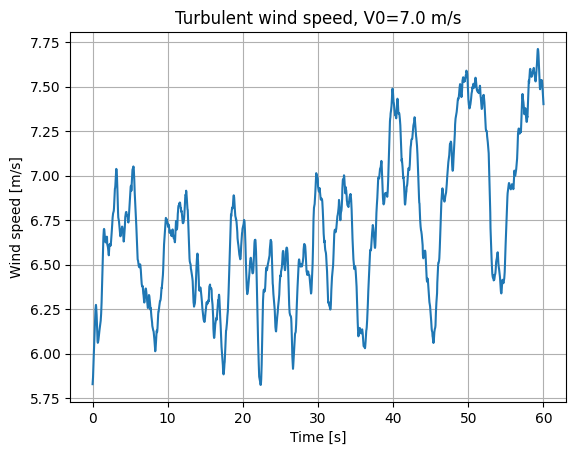

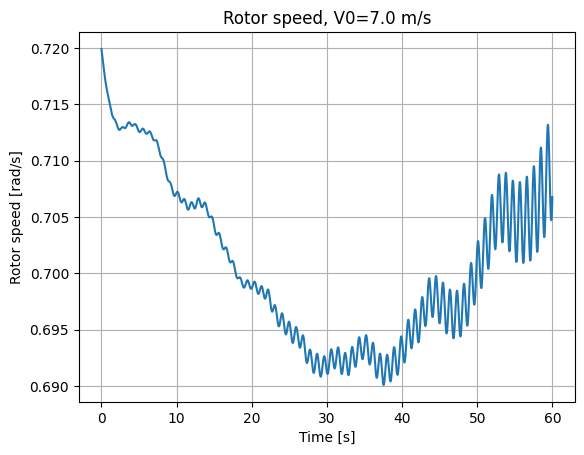

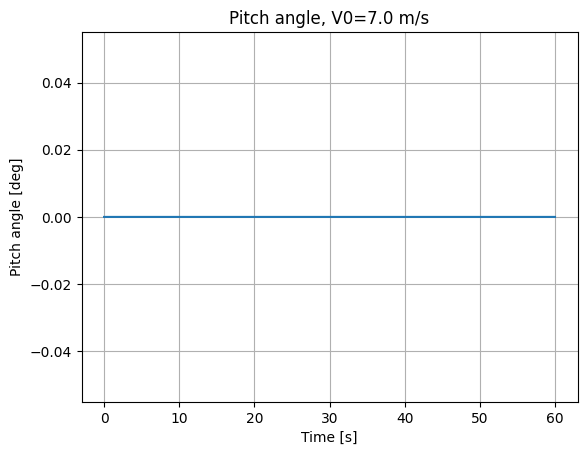

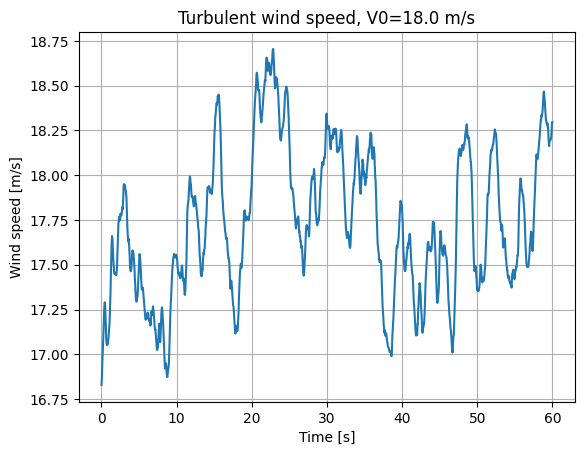

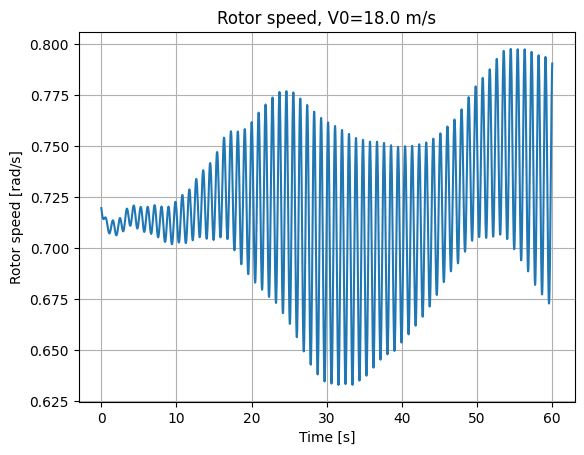

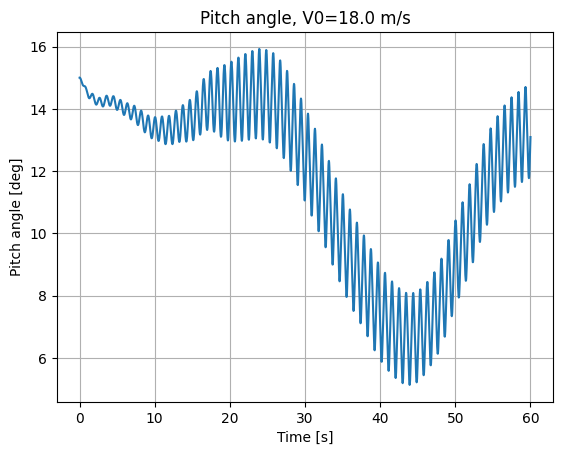

In [ ]:
# ============================================================
# Assignment 3 - Q1 validation plots
# Operating quantities: wind speed, rotor speed and pitch angle
# ============================================================
def plot_q1_operating(out, V0):
    """
    Plots operating conditions:
    - wind speed
    - rotor speed
    - pitch angle
    """

    t = out["t"]

    plt.figure()
    plt.plot(t, out["wind_hub"])
    plt.xlabel("Time [s]")
    plt.ylabel("Wind speed [m/s]")
    plt.title(f"Turbulent wind speed, V0={V0} m/s")
    plt.grid(True)

    plt.figure()
    plt.plot(t, out["omega"])
    plt.xlabel("Time [s]")
    plt.ylabel("Rotor speed [rad/s]")
    plt.title(f"Rotor speed, V0={V0} m/s")
    plt.grid(True)

    plt.figure()
    plt.plot(t, out["pitch"])
    plt.xlabel("Time [s]")
    plt.ylabel("Pitch angle [deg]")
    plt.title(f"Pitch angle, V0={V0} m/s")
    plt.grid(True)

    plt.show()


plot_q1_operating(out7_turb, V0=7.0)
plot_q1_operating(out18_turb, V0=18.0)